In [1]:

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

(X_train, y_train), (X_test,y_test) = datasets.cifar10.load_data()
X_train.shape

(50000, 32, 32, 3)

In [2]:
X_test.shape

(10000, 32, 32, 3)

In [3]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [4]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [5]:
y_test = y_test.reshape(-1,)

In [6]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [7]:
def plot_sample(X, y, index):
    plt.figure(figsize = (15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

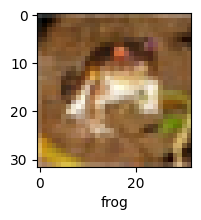

In [8]:
plot_sample(X_train, y_train, 0)

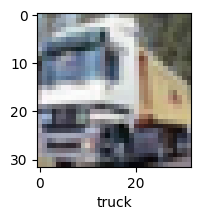

In [9]:
plot_sample(X_train, y_train, 1)

In [10]:
X_train = X_train / 255.0
X_test = X_test / 255.0
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.02),
    layers.RandomZoom(0.1),
])
print("X_train max:", X_train.max())

X_train max: 1.0


In [11]:
sample = X_train[0]
sample_batch = np.expand_dims(sample, 0)

In [12]:
augmented = data_augmentation(sample_batch)


In [13]:
print("X_train max:", X_train.max())

X_train max: 1.0


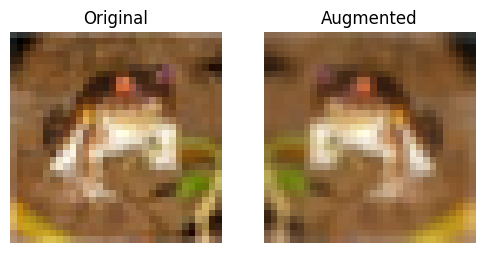

In [14]:
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(sample)
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
aug_img = np.clip(augmented[0].numpy(), 0, 1)
plt.imshow(aug_img)
plt.title("Augmented")
plt.axis('off')
plt.show()

In [15]:
print("Original sample:")
print("  dtype:", sample.dtype)
print("  min:", sample.min(), "max:", sample.max())

print("Augmented:")
print("  type:", type(augmented))
aug = augmented[0].numpy() if hasattr(augmented[0], 'numpy') else augmented[0]
print("  dtype:", aug.dtype)
print("  min:", aug.min(), "max:", aug.max())
print("  shape:", aug.shape)

Original sample:
  dtype: float64
  min: 0.0 max: 1.0
Augmented:
  type: <class 'tensorflow.python.framework.ops.EagerTensor'>
  dtype: float32
  min: 0.032507733 max: 0.9987501
  shape: (32, 32, 3)


In [16]:
print("X_train max:", X_train.max())
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train max: 1.0
X_train shape: (50000, 32, 32, 3)
y_train shape: (50000,)


In [17]:
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax'),
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [20]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 63ms/step - accuracy: 0.7390 - loss: 0.7566 - val_accuracy: 0.7272 - val_loss: 0.8232 - learning_rate: 0.0010
Epoch 2/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.7531 - loss: 0.7244 - val_accuracy: 0.7580 - val_loss: 0.7215 - learning_rate: 0.0010
Epoch 3/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 84ms/step - accuracy: 0.7538 - loss: 0.7089 - val_accuracy: 0.7635 - val_loss: 0.7182 - learning_rate: 0.0010
Epoch 4/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 87ms/step - accuracy: 0.7628 - loss: 0.6929 - val_accuracy: 0.7728 - val_loss: 0.6761 - learning_rate: 0.0010
Epoch 5/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 88s 95ms/step - accuracy: 0.7736 - loss: 0.6659 - val_accuracy: 0.7755 - val_loss: 0.6828 - learning_rate: 0.0010
Epoch 6/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 69s 88ms/step - accuracy: 0.7779 - loss: 0.6485 - val_accuracy: 0.7727 - val_loss: 0.7048 - learning_rate: 0.0010
Epoch 7/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 87ms/step - accuracy: 0.7879 - l

In [21]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8202 - loss: 0.5904


[0.5846676826477051, 0.8177000284194946]

In [22]:
y_pred = model.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


array([[4.2589450e-05, 1.4258088e-05, 1.3980051e-04, 9.3310994e-01,
        5.0436869e-05, 6.5958671e-02, 5.4306747e-05, 2.2110957e-04,
        4.0124689e-04, 7.5541643e-06],
       [1.7060540e-09, 4.4204542e-04, 3.6744758e-16, 7.7698832e-15,
        1.7364472e-17, 2.0650012e-18, 2.4058872e-15, 1.1102974e-19,
        9.9955791e-01, 1.5580350e-10],
       [5.7580166e-02, 1.3324970e-01, 7.8996129e-07, 7.0879537e-06,
        2.8894550e-07, 6.2398271e-08, 4.6454911e-08, 1.1299103e-07,
        7.9627639e-01, 1.2885334e-02],
       [9.0312958e-01, 3.7243473e-05, 7.3174328e-02, 1.5383934e-03,
        8.6749019e-04, 6.9362322e-05, 4.0750278e-05, 7.9745303e-05,
        2.0910196e-02, 1.5282292e-04],
       [6.7568390e-15, 5.5528802e-13, 2.0474120e-04, 3.6048063e-05,
        2.3883089e-02, 6.5412196e-09, 9.7587615e-01, 5.0641582e-13,
        4.6228945e-12, 8.1108595e-13]], dtype=float32)

In [24]:
pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.9 MB 1.4 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/8.9 MB 1.3 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/8.9 MB 1.0 MB/s eta 0:00:08
   ----- ---------------------------------- 1.3/8.9 MB 1.1 MB/s eta 0:00:07
   -------- ------------------------------- 1.8/8.9 MB 1.3 MB/s eta 0:00:06
   --------- ------------------------------ 2.1/8.9 MB 1.3 MB/s eta 0:00:06
   ----------- ---------------------------- 2.6/8.9 MB 1.5 MB/s eta 0:00:05
   ------------ --------------------------- 2.9/8.9 MB 1.5 MB/s eta 0:00:05
   -------------- ------------------------- 3.1/8.9 M


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.81      0.86      0.83      1000
           1       0.90      0.93      0.91      1000
           2       0.77      0.73      0.75      1000
           3       0.68      0.63      0.66      1000
           4       0.80      0.81      0.80      1000
           5       0.80      0.69      0.74      1000
           6       0.79      0.90      0.84      1000
           7       0.85      0.85      0.85      1000
           8       0.92      0.88      0.90      1000
           9       0.85      0.90      0.87      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000



In [27]:
import sys
!{sys.executable} -m pip install seaborn scikit-learn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


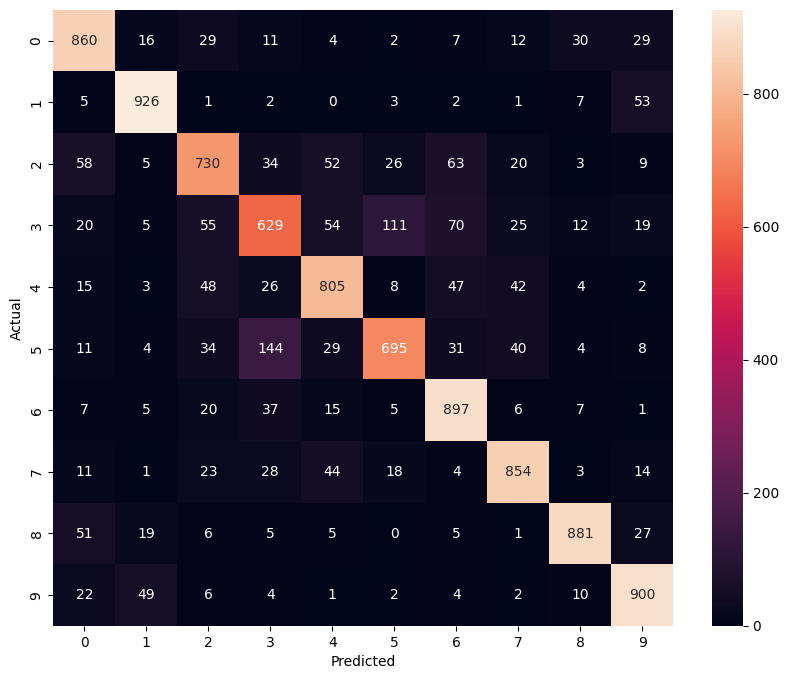

Classification Report: 
               precision    recall  f1-score   support

           0       0.81      0.86      0.83      1000
           1       0.90      0.93      0.91      1000
           2       0.77      0.73      0.75      1000
           3       0.68      0.63      0.66      1000
           4       0.80      0.81      0.80      1000
           5       0.80      0.69      0.74      1000
           6       0.79      0.90      0.84      1000
           7       0.85      0.85      0.85      1000
           8       0.92      0.88      0.90      1000
           9       0.85      0.90      0.87      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

predicted = model.predict(X_test)
predicted = np.array([np.argmax(element) for element in predicted])

actual = y_test

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification report
print("Classification Report: \n", classification_report(actual, predicted))

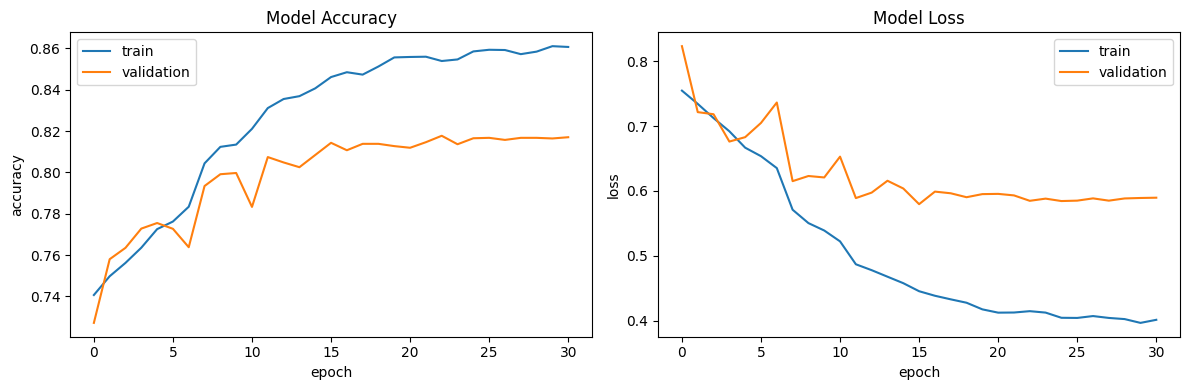

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.title('Model Accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.title('Model Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

plt.tight_layout()
plt.savefig('training_validation_curves.png', dpi=120)
plt.show()